# Dataset

In [33]:
# dataset.py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class DrivingDataset(Dataset):
    def __init__(self, npz_path: str):
        super().__init__()
        D = np.load(npz_path)

        # ---- Controls: [B,200] = (100 vel + 100 steer) ----
        controls = D["controls"].astype(np.float32)
        self.controls = controls

        # ---- Ego (8) + Lane (2) -> Ego(10) ----
        ego = D["ego"].astype(np.float32)
        x, y, vx, vy, ax, ay, psi, psidot = [ego[:, i] for i in range(8)]

        lane = D["lane"].astype(np.float32)
        y_lb, y_ub = lane[:, 0], lane[:, 1]

        ego_feats = np.stack(
            [x, y, vx, vy, ax, ay, psi, psidot, y_lb, y_ub], axis=1
        ).astype(np.float32)

        # ---- Obstacles: obs [B,56] -> [B,7,8] -> PN features [B,8,8] ----
        obs_flat = D["obs"].astype(np.float32)
        B = obs_flat.shape[0]
        N_obs, FEATS_PER_OBS = 8, 7

        obs_blocks = obs_flat.reshape(B, FEATS_PER_OBS, N_obs)
        x_o, y_o, vx_o, vy_o, psi_o, dimx_o, dimy_o = [obs_blocks[:, i, :] for i in range(7)]

        relx   = x_o - x[:, None]
        rely   = y_o - y[:, None]
        cospsi = np.cos(psi_o)
        sinpsi = np.sin(psi_o)

        obs_feats = np.stack(
            [relx, rely, vx_o, vy_o, cospsi, sinpsi, dimx_o, dimy_o], axis=2
        ).astype(np.float32)  

        # ---- Normalization (dataset-wide) ----
        self.B     = B
        self.N_obs = N_obs

        self.ego_mean = ego_feats.mean(axis=0)
        self.ego_std  = ego_feats.std(axis=0) + 1e-6

        obs_flat_8 = obs_feats.reshape(self.B * self.N_obs, -1)
        self.obs_mean = obs_flat_8.mean(axis=0)
        self.obs_std  = obs_flat_8.std(axis=0) + 1e-6

        self.ego_feats = ego_feats
        self.obs_feats = obs_feats

    def __len__(self):
        return self.B

    def __getitem__(self, i: int):
        # Normalize ego & obstacles
        ego = (self.ego_feats[i] - self.ego_mean) / self.ego_std          
        obs = (self.obs_feats[i] - self.obs_mean) / self.obs_std          

        # Controls: first 100 velocity, next 100 steering
        vel   = self.controls[i, :100]
        steer = self.controls[i, 100:200]
        y = np.stack([vel, steer], axis=0).astype(np.float32)              

        return torch.from_numpy(ego), torch.from_numpy(obs), torch.from_numpy(y)

def make_loader(npz_path, batch_size=128, shuffle=True, num_workers=4, pin_memory=True):
    ds = DrivingDataset(npz_path)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
        drop_last=False
    )
    return ds, dl


In [ ]:
# #!/usr/bin/env python3
# import os, time
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, random_split
# from model2 import PolicySeqFlow             

# # --------------------------
# # Config
# # --------------------------
# DATA_FILE       = "./data_train.npz"
# SAVE_DIR        = "./checkpoints"
# os.makedirs(SAVE_DIR, exist_ok=True)

# DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
# BATCH_SIZE      = 1024
# EPOCHS          = 100
# LR              = 1e-4
# CLIP_GRAD_NORM  = 5.0
# CKPT_PATH       = os.path.join(SAVE_DIR, "seq_flow_velsteer.pt")
# CKPT_BEST_PATH  = os.path.join(SAVE_DIR, "seq_flow_velsteer_best.pt")

# # --------------------------
# # Training (+ validation)
# # --------------------------
# def train():
   
#     full_ds = DrivingDataset(DATA_FILE)
#     n_total = len(full_ds)
#     n_val   = max(1, int(0.1 * n_total))
#     n_train = n_total - n_val
#     train_ds, val_ds = random_split(full_ds, [n_train, n_val],
#                                     generator=torch.Generator().manual_seed(42))

#     train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
#     val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

#     model = PolicySeqFlow().to(DEVICE)          # horizon=100 inside your model/dataset design
#     opt   = torch.optim.Adam(model.parameters(), lr=LR)

#     best_val = float("inf")

#     for ep in range(1, EPOCHS+1):
#         # ===== train =====
#         model.train()
#         t0 = time.time()
#         train_running = 0.0
#         for ego, obs, y in train_dl:
#             ego, obs, y = ego.to(DEVICE), obs.to(DEVICE), y.to(DEVICE)   

#             # # y: [B,2,H]
#             # B, _, H = y.shape
#             # h_idx  = torch.randint(0, H, (B,), device=DEVICE)
#             # x1     = y.gather(2, h_idx.view(B,1,1).expand(B,2,1)).squeeze(-1)      # [B,2]
#             # h_prev = torch.clamp(h_idx - 1, min=0)
#             # a_prev = y.gather(2, h_prev.view(B,1,1).expand(B,2,1)).squeeze(-1)     # [B,2]
#             # a_prev = torch.where((h_idx==0).view(B,1), torch.zeros_like(a_prev), a_prev)

#             # x0 = torch.randn_like(x1)
#             # t  = torch.rand(B,1, device=DEVICE)
#             # x_t  = (1 - t)*x0 + t*x1
#             # dx_t = (x1 - x0)

#             # ctx  = model.context(ego, obs)                       # [B,128]
#             # cond = model.cond_for_indices(ctx, h_idx, a_prev)    # [B,194]
#             # pred = model.fm(t, x_t, cond)                        # first Linear expects 197 inputs
#             # loss = ((pred - dx_t)**2).mean()

#             B = y.size(0)
#             h_idx = torch.randint(0, 100, (B,), device=DEVICE)           
#             x1 = y.gather(2, h_idx.view(B,1,1).expand(B,2,1)).squeeze(-1)  
#             x0 = torch.randn_like(x1)                                      
#             t  = torch.rand(B,1, device=DEVICE)                            
#             x_t  = (1 - t) * x0 + t * x1
#             dx_t = (x1 - x0)

#             ctx  = model.context(ego, obs)                                  
#             pred = model.fm(t, x_t, ctx)                                    
#             loss = torch.mean((pred - dx_t)**2)

#             opt.zero_grad(set_to_none=True)
#             loss.backward()
#             nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
#             opt.step()

#             train_running += loss.item()

#         train_loss = train_running / max(1, len(train_dl))

#         # ===== validate =====
#         model.eval()
#         val_running = 0.0
#         with torch.no_grad():
#             for ego, obs, y in val_dl:
#                 ego, obs, y = ego.to(DEVICE), obs.to(DEVICE), y.to(DEVICE)

#                 # B, _, H = y.shape
#                 # h_idx  = torch.randint(0, H, (B,), device=DEVICE)
#                 # x1     = y.gather(2, h_idx.view(B,1,1).expand(B,2,1)).squeeze(-1)     # [B,2]
#                 # h_prev = torch.clamp(h_idx - 1, min=0)
#                 # a_prev = y.gather(2, h_prev.view(B,1,1).expand(B,2,1)).squeeze(-1)    # [B,2]
#                 # a_prev = torch.where((h_idx==0).view(B,1), torch.zeros_like(a_prev), a_prev)

#                 # x0 = torch.randn_like(x1)
#                 # t  = torch.rand(B,1, device=DEVICE)
#                 # x_t  = (1 - t) * x0 + t * x1
#                 # dx_t = (x1 - x0)

#                 # ctx  = model.context(ego, obs)                         # [B,128]
#                 # cond = model.cond_for_indices(ctx, h_idx, a_prev)      # [B,194]
#                 # pred = model.fm(t, x_t, cond)                          # OK (expects 197)
#                 # vloss = ((pred - dx_t)**2).mean()

#                 # val_running += vloss.item()
                
#                 B = y.size(0)
#                 h_idx = torch.randint(0, 100, (B,), device=DEVICE)
#                 x1 = y.gather(2, h_idx.view(B,1,1).expand(B,2,1)).squeeze(-1)
#                 x0 = torch.randn_like(x1)
#                 t  = torch.rand(B,1, device=DEVICE)
#                 x_t  = (1 - t) * x0 + t * x1
#                 dx_t = (x1 - x0)

#                 ctx  = model.context(ego, obs)
#                 pred = model.fm(t, x_t, ctx)
#                 vloss = torch.mean((pred - dx_t)**2)

#                 val_running += vloss.item()

#         val_loss = val_running / max(1, len(val_dl))
#         print(f"Epoch {ep:03d} | train {train_loss:.6f} | val {val_loss:.6f} | time {time.time()-t0:.1f}s")

#         if val_loss < best_val:
#             best_val = val_loss
#             torch.save(model.state_dict(), CKPT_BEST_PATH)
#             print(f"  ↳ new best, saved → {CKPT_BEST_PATH}")

#     torch.save(model.state_dict(), CKPT_PATH)
#     print(f"Saved final model → {CKPT_PATH}")
#     return model

# if __name__ == "__main__":
#     train()


In [5]:
# ============================
# FB-style training with everything wired
# (uses your DrivingDataset exactly as written)
# ============================
import os, time, math, torch
from torch.utils.data import DataLoader, random_split
# If your model lives in another file, uncomment ONE of these:
from model2 import PolicySeqFlow
# from flow_model import PolicySeqFlow

# ---- Config ----
DATA_FILE   = "./data_train.npz"
SAVE_DIR    = "./checkpoints"
BATCH_SIZE  = 256
VAL_SPLIT   = 0.10
LR          = 1e-4
EPOCHS      = 100
CLIP        = 5.0
SEED        = 42
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(SAVE_DIR, exist_ok=True)
torch.manual_seed(SEED)

# ---- Build dataset + loaders (no changes to your dataset code) ----
ds_full = DrivingDataset(DATA_FILE)
H       = ds_full.controls.shape[1] // 2  # 200 -> H=100

n_total = len(ds_full)
n_val   = max(1, int(VAL_SPLIT * n_total))
n_train = n_total - n_val
tr_ds, va_ds = random_split(ds_full, [n_train, n_val],
                            generator=torch.Generator().manual_seed(SEED))

train_dl = DataLoader(
    tr_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True,
    persistent_workers=True, drop_last=False
)
val_dl = DataLoader(
    va_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True,
    persistent_workers=True, drop_last=False
)

# ---- Model ----
model = PolicySeqFlow(ctx_dim=128, horizon=H, hidden=256).to(DEVICE)

# ----- FB helpers (unchanged FB loss) -----
def _fm_batch_prep(y, device):
    """y:[B,2,H] -> (t:[B,1], x_t:[B,2H], dx_t:[B,2H])"""
    B, _, H = y.shape
    x1 = y.permute(0, 2, 1).reshape(B, 2*H)      # [B,2H]
    x0 = torch.randn_like(x1)                     # [B,2H]
    t  = torch.rand(B, 1, device=device)         # [B,1]
    x_t  = (1.0 - t) * x0 + t * x1               # [B,2H]
    dx_t = (x1 - x0)                              # [B,2H]
    return t, x_t, dx_t, H

def train_epoch_fb(model, optimizer, train_dl, device, clip=5.0):
    model.train()
    total = 0.0
    for ego, obs, y in train_dl:
        ego = ego.to(device, non_blocking=True)   # [B,10]
        obs = obs.to(device, non_blocking=True)   # [B,8,8]
        y   = y.to(device, non_blocking=True)     # [B,2,H]

        t, x_t, dx_t, H_ = _fm_batch_prep(y, device)
        if hasattr(model, "horizon") and model.horizon != H_:
            raise ValueError(f"Model horizon {model.horizon} != data horizon {H_}")

        ctx  = model.context(ego, obs)            # [B,C]
        pred = model.fm(t, x_t, ctx)              # [B,2H]

        loss = torch.mean((pred - dx_t)**2)       # FB loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total += loss.item()
    return total / max(1, len(train_dl))

@torch.no_grad()
def eval_epoch_fb(model, val_dl, device):
    model.eval()
    total = 0.0
    for ego, obs, y in val_dl:
        ego = ego.to(device, non_blocking=True)
        obs = obs.to(device, non_blocking=True)
        y   = y.to(device, non_blocking=True)

        t, x_t, dx_t, H_ = _fm_batch_prep(y, device)
        if hasattr(model, "horizon") and model.horizon != H_:
            raise ValueError(f"Model horizon {model.horizon} != data horizon {H_}")

        ctx  = model.context(ego, obs)
        pred = model.fm(t, x_t, ctx)

        loss = torch.mean((pred - dx_t)**2)       # FB val loss
        total += loss.item()
    return total / max(1, len(val_dl))

def train_like_fb(model,
                  train_dl,
                  val_dl,
                  epochs=EPOCHS,
                  lr=LR,
                  device=DEVICE,
                  clip=CLIP,
                  ckpt_best_path=os.path.join(SAVE_DIR, "fb_best.pt"),
                  ckpt_last_path=os.path.join(SAVE_DIR, "fb_last.pt")):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_val = math.inf

    for ep in range(1, epochs+1):
        t0 = time.time()
        tr = train_epoch_fb(model, opt, train_dl, device, clip=clip)
        va = eval_epoch_fb(model, val_dl, device)
        print(f"Epoch {ep:03d} | train {tr:.6f} | val {va:.6f} | {time.time()-t0:.1f}s")

        if va < best_val:
            best_val = va
            torch.save(model.state_dict(), ckpt_best_path)

        torch.save(model.state_dict(), ckpt_last_path)

    return model

# ---- Run training ----
model = train_like_fb(model, train_dl, val_dl)
print("Done. Best/last checkpoints saved in:", SAVE_DIR)


Epoch 001 | train 1.734064 | val 1.184113 | 8.8s
Epoch 002 | train 1.104250 | val 1.061591 | 8.1s


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a11843c55a0>
Traceback (most recent call last):
  File "/home/sazid/jax-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/sazid/jax-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a11843c55a0>
Traceback (most recent call last):
  File "/home/sazid/jax-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/sazid/jax-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
  

Epoch 003 | train 0.975234 | val 0.920598 | 9.1s
Epoch 004 | train 0.883858 | val 0.838730 | 8.9s
Epoch 005 | train 0.810414 | val 0.778802 | 8.2s
Epoch 006 | train 0.757201 | val 0.737579 | 7.9s
Epoch 007 | train 0.713402 | val 0.697753 | 7.9s
Epoch 008 | train 0.677472 | val 0.656739 | 7.9s
Epoch 009 | train 0.646071 | val 0.631202 | 7.8s
Epoch 010 | train 0.618232 | val 0.607743 | 8.3s


Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a11843c55a0><function _MultiProcessingDataLoaderIter.__del__ at 0x7a11843c55a0>

Traceback (most recent call last):
  File "/home/sazid/jax-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
Traceback (most recent call last):
  File "/home/sazid/jax-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/home/sazid/jax-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
  File "/home/sazid/jax-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
        if w.is_alive():if w.is_alive():

  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
        assert self._par

Epoch 011 | train 0.594488 | val 0.590815 | 7.9s
Epoch 012 | train 0.573943 | val 0.562083 | 7.8s
Epoch 013 | train 0.553000 | val 0.551071 | 8.2s
Epoch 014 | train 0.536453 | val 0.532472 | 7.9s
Epoch 015 | train 0.518306 | val 0.507800 | 8.1s
Epoch 016 | train 0.501841 | val 0.494211 | 8.4s
Epoch 017 | train 0.486273 | val 0.472951 | 8.1s
Epoch 018 | train 0.471173 | val 0.461059 | 8.0s
Epoch 019 | train 0.459164 | val 0.450853 | 7.8s
Epoch 020 | train 0.447823 | val 0.434723 | 7.9s
Epoch 021 | train 0.435857 | val 0.430764 | 7.8s
Epoch 022 | train 0.428393 | val 0.417762 | 8.0s
Epoch 023 | train 0.418541 | val 0.411332 | 7.6s
Epoch 024 | train 0.409234 | val 0.402028 | 7.7s
Epoch 025 | train 0.400157 | val 0.403480 | 7.8s
Epoch 026 | train 0.391885 | val 0.396964 | 7.7s
Epoch 027 | train 0.382042 | val 0.374198 | 8.1s
Epoch 028 | train 0.374996 | val 0.368439 | 7.7s
Epoch 029 | train 0.368934 | val 0.374126 | 7.8s
Epoch 030 | train 0.361287 | val 0.364973 | 7.9s
Epoch 031 | train 0.

In [ ]:
# vel_std = ds.controls[:, :100].std(axis=1)
# ste_std = ds.controls[:, 100:200].std(axis=1)

# idx_most_dynamic = int(np.argmax(vel_std + ste_std))
# print("Most dynamic sequence idx:", idx_most_dynamic)


Most dynamic sequence idx: 445917


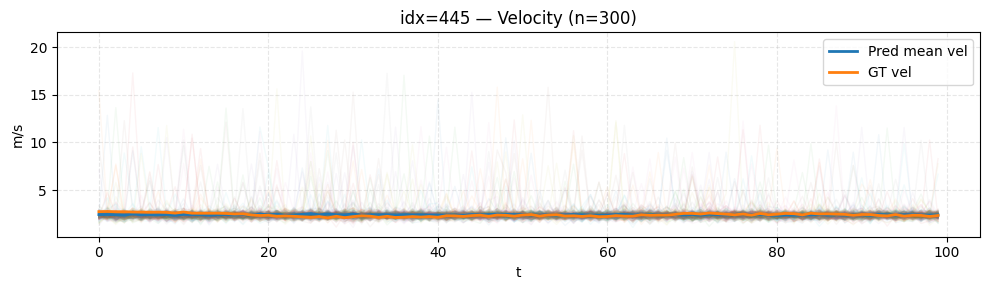

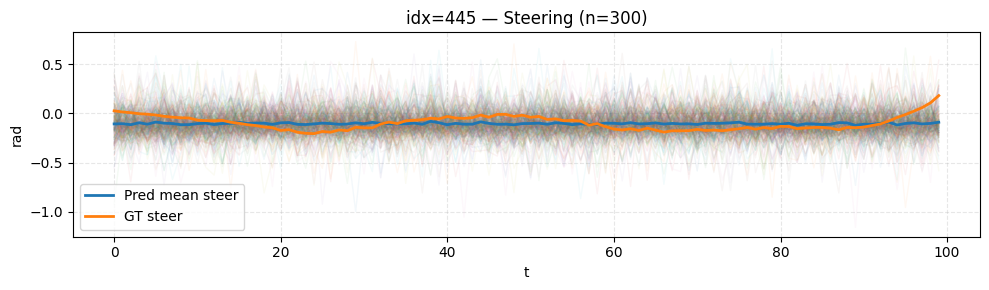

[idx=445] MAE vel=0.1381 | MAE steer=0.0597


In [ ]:
# # --- draw_300.py (or paste into your train/eval script) ---
# import numpy as np
# import torch
# import matplotlib.pyplot as plt

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# @torch.no_grad()
# def sample_sequences(model, ego, obs, n_samples=300, n_int=128, sigma=1.5):
#     """
#     Returns: samples [n_samples, B, 2, H]
#     """
#     model.eval()
#     ego, obs = ego.to(DEVICE), obs.to(DEVICE)
#     ctx = model.context(ego, obs)                 # [B,128]
#     B = ctx.size(0); H = 100

#     # Repeat ctx for every horizon step, then flatten to [B*H, ctx_dim]
#     cond = ctx[:, None, :].expand(B, H, -1).reshape(B * H, -1)

#     # Time grid for midpoint integration
#     t_grid = torch.linspace(0.0, 1.0, n_int + 1, device=ctx.device)

#     all_samples = []
#     for _ in range(n_samples):
#         # x0 ~ N(0, sigma^2 I) for every (batch,h)
#         x = torch.randn(B * H, 2, device=ctx.device) * sigma
#         for i in range(n_int):
#             t0  = t_grid[i].view(1, 1).expand(B * H, 1)
#             t1  = t_grid[i + 1].view(1, 1).expand(B * H, 1)
#             dt  = (t1 - t0)
#             tmid= t0 + 0.5 * dt
#             # Midpoint-in-time update (evaluate at (tmid, x))
#             x = x + dt * model.fm(tmid, x, cond)

#         x_seq = x.reshape(B, H, 2).permute(0, 2, 1).contiguous()  # [B,2,H]
#         all_samples.append(x_seq)

#     return torch.stack(all_samples, dim=0)  # [n, B, 2, H]

# @torch.no_grad()
# def plot_300_predictions_vs_gt(model, ds, idx=0, n_samples=300, n_int=128, sigma=1.5):
#     """
#     Draw 300 predicted sequences (thin, transparent) + GT (bold) + mean prediction.
#     """
#     ego, obs, y = ds[idx]                      # ego:[10], obs:[8,8], y:[2,H]
#     H = y.shape[-1]
#     ego = ego.unsqueeze(0).to(DEVICE)
#     obs = obs.unsqueeze(0).to(DEVICE)
#     y_np = y.numpy()
#     t = np.arange(H)

#     # Sample
#     S = sample_sequences(model, ego, obs, n_samples=n_samples, n_int=n_int, sigma=sigma)
#     S = S[:, 0].cpu().numpy()                  # [n,2,H] for this one item
#     mean_pred = S.mean(axis=0)                 # [2,H]

#     # --- Velocity plot ---
#     plt.figure(figsize=(10, 3))
#     for k in range(n_samples):
#         plt.plot(t, S[k, 0], alpha=0.05, linewidth=1)
#     plt.plot(t, mean_pred[0], label="Pred mean vel", linewidth=2)
#     plt.plot(t, y_np[0], label="GT vel", linewidth=2)
#     plt.title(f"idx={idx} — Velocity (n={n_samples})")
#     plt.xlabel("t"); plt.ylabel("m/s"); plt.grid(True, ls="--", alpha=0.3)
#     plt.legend(); plt.tight_layout(); plt.show()

#     # --- Steering plot ---
#     plt.figure(figsize=(10, 3))
#     for k in range(n_samples):
#         plt.plot(t, S[k, 1], alpha=0.05, linewidth=1)
#     plt.plot(t, mean_pred[1], label="Pred mean steer", linewidth=2)
#     plt.plot(t, y_np[1], label="GT steer", linewidth=2)
#     plt.title(f"idx={idx} — Steering (n={n_samples})")
#     plt.xlabel("t"); plt.ylabel("rad"); plt.grid(True, ls="--", alpha=0.3)
#     plt.legend(); plt.tight_layout(); plt.show()

#     # Quick MAE vs mean prediction
#     vel_mae = float(np.mean(np.abs(mean_pred[0] - y_np[0])))
#     ste_mae = float(np.mean(np.abs(mean_pred[1] - y_np[1])))
#     print(f"[idx={idx}] MAE vel={vel_mae:.4f} | MAE steer={ste_mae:.4f}")



# ds = DrivingDataset("./data_train.npz")
# model = PolicySeqFlow(horizon=100).to(DEVICE)
# model.load_state_dict(torch.load("./checkpoints/seq_flow_velsteer.pt", map_location=DEVICE))
# model.eval()

# plot_300_predictions_vs_gt(model, ds, idx=445, n_samples=300, n_int=128, sigma=1.5)


In [ ]:
# @torch.no_grad()
# def sample_sequences(model, ego, obs, n_samples=300, n_int=512, sigma=0.8,
#                      clamp_quantiles=None):
#     """
#     Returns: [n_samples, B, 2, H]
#     - n_int ↑ and sigma ↓ reduce spikes.
#     - clamp_quantiles: (low, high) tuple to clip to data range percentiles.
#     """
#     model.eval()
#     ego, obs = ego.to(DEVICE), obs.to(DEVICE)
#     ctx = model.context(ego, obs)                 # [B,128]
#     B = ctx.size(0); H = getattr(model, "horizon", 100)

#     cond = ctx[:, None, :].expand(B, H, -1).reshape(B * H, -1)
#     t_grid = torch.linspace(0.0, 1.0, n_int + 1, device=ctx.device)

#     # Optional: compute clipping bounds from dataset stats once outside this fn and pass in
#     if clamp_quantiles is not None:
#         v_lo, v_hi, s_lo, s_hi = clamp_quantiles  # scalars (numpy or torch)

#     samples = []
#     for _ in range(n_samples):
#         x = torch.randn(B * H, 2, device=ctx.device) * sigma  # x0

#         for i in range(n_int):
#             t0  = t_grid[i].view(1, 1).expand(B * H, 1)
#             t1  = t_grid[i+1].view(1, 1).expand(B * H, 1)
#             dt  = (t1 - t0)
#             tmid= t0 + 0.5 * dt

#             # ---- Proper RK2 (midpoint) ----
#             k1   = model.fm(t0,  x,           cond)      # [B*H,2]
#             xmid = x + 0.5 * dt * k1
#             k2   = model.fm(tmid, xmid,       cond)
#             x    = x + dt * k2

#             # Optional clamping to keep states in-data (prevents outlier spikes)
#             if clamp_quantiles is not None:
#                 # x[:,0] = velocity; x[:,1] = steer
#                 x[:, 0] = torch.clamp(x[:, 0], min=v_lo, max=v_hi)
#                 x[:, 1] = torch.clamp(x[:, 1], min=s_lo, max=s_hi)

#         x_seq = x.reshape(B, H, 2).permute(0, 2, 1).contiguous()  # [B,2,H]
#         samples.append(x_seq)

#     return torch.stack(samples, dim=0)  

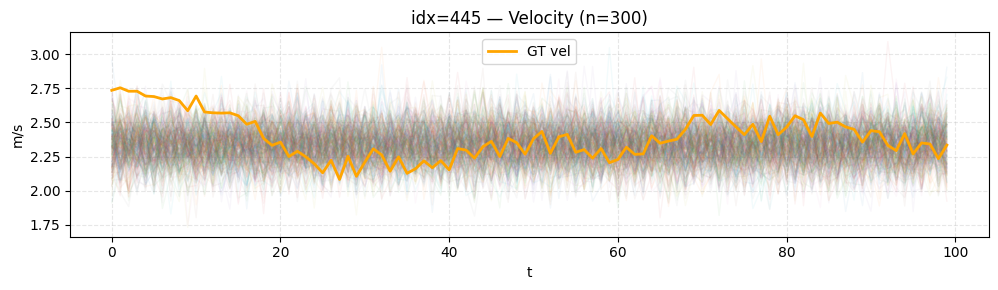

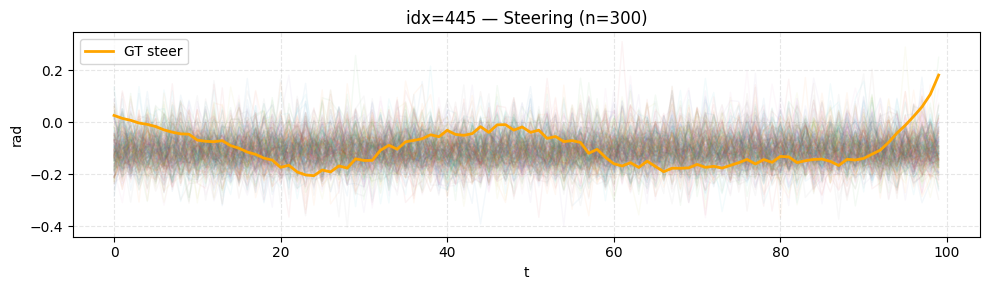

In [ ]:
# @torch.no_grad()
# def plot_300_predictions_no_mean(model, ds, idx=0, n_samples=300, n_int=128, sigma=1.5):
#     """
#     Draw 300 predicted sequences (thin, transparent) + GT (bold), no mean curve.
#     """
#     ego, obs, y = ds[idx]                      
#     H = y.shape[-1]
#     ego = ego.unsqueeze(0).to(DEVICE)
#     obs = obs.unsqueeze(0).to(DEVICE)
#     y_np = y.numpy()
#     t = np.arange(H)

#     # Sample
#     S = sample_sequences(model, ego, obs, n_samples=n_samples, n_int=n_int, sigma=sigma)
#     S = S[:, 0].cpu().numpy()                 

#     # --- Velocity plot ---
#     plt.figure(figsize=(10, 3))
#     for k in range(n_samples):
#         plt.plot(t, S[k, 0], alpha=0.05, linewidth=1)
#     plt.plot(t, y_np[0], label="GT vel", linewidth=2, color="orange")
#     plt.title(f"idx={idx} — Velocity (n={n_samples})")
#     plt.xlabel("t"); plt.ylabel("m/s"); plt.grid(True, ls="--", alpha=0.3)
#     plt.legend(); plt.tight_layout(); plt.show()

#     # --- Steering plot ---
#     plt.figure(figsize=(10, 3))
#     for k in range(n_samples):
#         plt.plot(t, S[k, 1], alpha=0.05, linewidth=1)
#     plt.plot(t, y_np[1], label="GT steer", linewidth=2, color="orange")
#     plt.title(f"idx={idx} — Steering (n={n_samples})")
#     plt.xlabel("t"); plt.ylabel("rad"); plt.grid(True, ls="--", alpha=0.3)
#     plt.legend(); plt.tight_layout(); plt.show()

# plot_300_predictions_no_mean(model, ds, idx=445, n_samples=300, n_int=512, sigma=0.8)


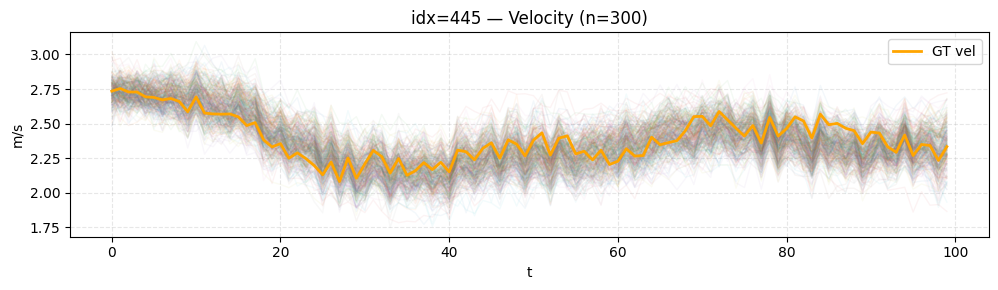

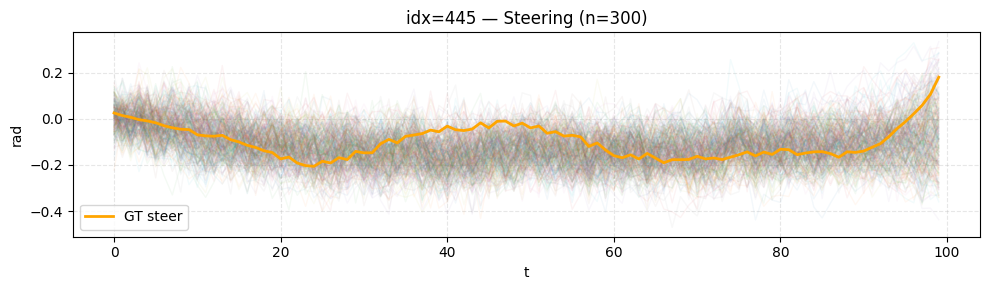

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def sample_sequences(model, ego, obs, n_samples=300, n_int=512, sigma=0.8,
                     clamp_quantiles=None):
    """
    Returns: [n_samples, B, 2, H]
    Works with FMSeq (trajectory head): x ∈ R^{2H}, not per-timestep.
    """
    device = next(model.parameters()).device
    model.eval()

    ego, obs = ego.to(device), obs.to(device)
    ctx = model.context(ego, obs)                 # [B, C]
    B = ctx.size(0); H = getattr(model, "horizon", 100)

    ts = torch.linspace(0.0, 1.0, n_int + 1, device=device)

    if clamp_quantiles is not None:
        v_lo, v_hi, s_lo, s_hi = clamp_quantiles  # scalars or tensors on CPU/GPU ok

    samples = []
    for _ in range(n_samples):
        # start from noise in trajectory space
        x = torch.randn(B, 2 * H, device=device) * sigma  # [B,2H]

        for i in range(n_int):
            t0, t1 = ts[i], ts[i+1]
            x = model.fm.step(x, t0, t1, ctx)             # Heun midpoint inside

            if clamp_quantiles is not None:
                xv = x.view(B, H, 2)                      # [B,H,2] -> clamp per channel
                xv[..., 0] = xv[..., 0].clamp(v_lo, v_hi) # velocity
                xv[..., 1] = xv[..., 1].clamp(s_lo, s_hi) # steering
                x = xv.view(B, 2 * H)

        x_seq = x.view(B, H, 2).permute(0, 2, 1).contiguous()  # [B,2,H]
        samples.append(x_seq)

    return torch.stack(samples, dim=0)  # [n_samples, B, 2, H]


@torch.no_grad()
def plot_300_predictions_no_mean(model, ds, idx=0, n_samples=300, n_int=128, sigma=1.5,
                                 clamp_quantiles=None):
    """
    Draw 300 sampled sequences (thin) + GT (bold), no mean curve.
    """
    ego, obs, y = ds[idx]                         
    H = y.shape[-1]
    device = next(model.parameters()).device

    ego = ego.unsqueeze(0).to(device)             
    obs = obs.unsqueeze(0).to(device)            
    y_np = y.numpy()
    t = np.arange(H)

    # Sample from FMSeq trajectory head
    S = sample_sequences(model, ego, obs, n_samples=n_samples, n_int=n_int,
                         sigma=sigma, clamp_quantiles=clamp_quantiles)  
    S = S[:, 0].cpu().numpy()                     

    # --- Velocity ---
    plt.figure(figsize=(10, 3))
    for k in range(n_samples):
        plt.plot(t, S[k, 0], alpha=0.05, linewidth=1)
    plt.plot(t, y_np[0], label="GT vel", linewidth=2, color="orange")
    plt.title(f"idx={idx} — Velocity (n={n_samples})")
    plt.xlabel("t"); plt.ylabel("m/s"); plt.grid(True, ls="--", alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

    # --- Steering ---
    plt.figure(figsize=(10, 3))
    for k in range(n_samples):
        plt.plot(t, S[k, 1], alpha=0.05, linewidth=1)
    plt.plot(t, y_np[1], label="GT steer", linewidth=2, color="orange")
    plt.title(f"idx={idx} — Steering (n={n_samples})")
    plt.xlabel("t"); plt.ylabel("rad"); plt.grid(True, ls="--", alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

ds = DrivingDataset("./data_train.npz")
model = 
plot_300_predictions_no_mean(model, ds, idx=445, n_samples=300, n_int=512, sigma=0.8)


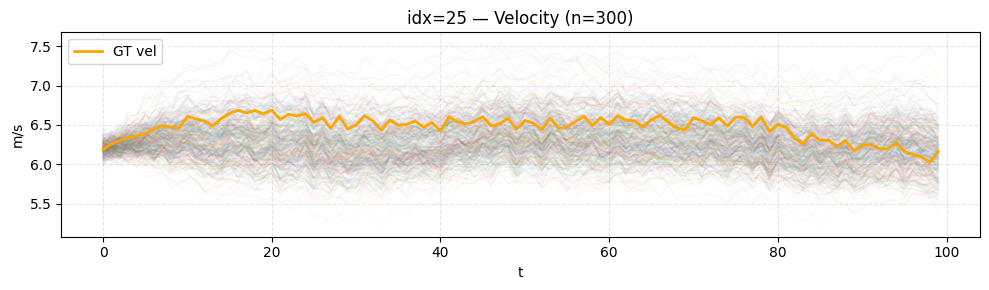

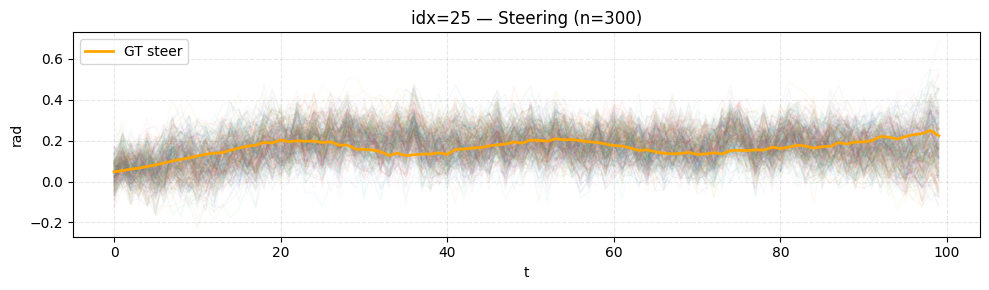

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt
@torch.no_grad()
def sample_sequences(model, ego, obs, n_samples=300, n_int=512, sigma=0.8,
                     clamp_quantiles=None):
    """
    Returns: [n_samples, B, 2, H]
    Works with FMSeq (trajectory head): x ∈ R^{2H}, not per-timestep.
    """
    device = next(model.parameters()).device
    model.eval()

    ego, obs = ego.to(device), obs.to(device)
    ctx = model.context(ego, obs)                 # [B, C]
    B = ctx.size(0); H = getattr(model, "horizon", 100)

    ts = torch.linspace(0.0, 1.0, n_int + 1, device=device)

    if clamp_quantiles is not None:
        v_lo, v_hi, s_lo, s_hi = clamp_quantiles  # scalars or tensors on CPU/GPU ok

    samples = []
    for _ in range(n_samples):
        # start from noise in trajectory space
        x = torch.randn(B, 2 * H, device=device) * sigma  # [B,2H]

        for i in range(n_int):
            t0, t1 = ts[i], ts[i+1]
            x = model.fm.step(x, t0, t1, ctx)             # Heun midpoint inside

            if clamp_quantiles is not None:
                xv = x.view(B, H, 2)                      # [B,H,2] -> clamp per channel
                xv[..., 0] = xv[..., 0].clamp(v_lo, v_hi) # velocity
                xv[..., 1] = xv[..., 1].clamp(s_lo, s_hi) # steering
                x = xv.view(B, 2 * H)

        x_seq = x.view(B, H, 2).permute(0, 2, 1).contiguous()  # [B,2,H]
        samples.append(x_seq)

    return torch.stack(samples, dim=0)  # [n_samples, B, 2, H]


@torch.no_grad()
def plot_300_predictions_no_mean(model, ds, idx=0, n_samples=300, n_int=128, sigma=1.5,
                                 clamp_quantiles=None):
    """
    Draw 300 sampled sequences (thin) + GT (bold), no mean curve.
    """
    ego, obs, y = ds[idx]                         # ego:[10], obs:[8,8], y:[2,H]
    H = y.shape[-1]
    device = next(model.parameters()).device

    ego = ego.unsqueeze(0).to(device)             # [1,10]
    obs = obs.unsqueeze(0).to(device)             # [1,8,8]
    y_np = y.numpy()
    t = np.arange(H)

    # Sample from FMSeq trajectory head
    S = sample_sequences(model, ego, obs, n_samples=n_samples, n_int=n_int,
                         sigma=sigma, clamp_quantiles=clamp_quantiles)  # [n,B,2,H]
    S = S[:, 0].cpu().numpy()                     # [n,2,H] (B=1)

    # --- Velocity ---
    plt.figure(figsize=(10, 3))
    for k in range(n_samples):
        plt.plot(t, S[k, 0], alpha=0.05, linewidth=1)
    plt.plot(t, y_np[0], label="GT vel", linewidth=2, color="orange")
    plt.title(f"idx={idx} — Velocity (n={n_samples})")
    plt.xlabel("t"); plt.ylabel("m/s"); plt.grid(True, ls="--", alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

    # --- Steering ---
    plt.figure(figsize=(10, 3))
    for k in range(n_samples):
        plt.plot(t, S[k, 1], alpha=0.05, linewidth=1)
    plt.plot(t, y_np[1], label="GT steer", linewidth=2, color="orange")
    plt.title(f"idx={idx} — Steering (n={n_samples})")
    plt.xlabel("t"); plt.ylabel("rad"); plt.grid(True, ls="--", alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

ds = DrivingDataset("./data_train.npz")
plot_300_predictions_no_mean(model, ds, idx=25, n_samples=300, n_int=512, sigma=0.8)


In [40]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from model2 import PolicySeqFlow

@torch.no_grad()
def sample_sequences(model, ego, obs, n_samples=300, n_int=512, sigma=0.8,
                     clamp_quantiles=None):
    """
    Returns: [n_samples, B, 2, H]
    Works with FMSeq (trajectory head): x ∈ R^{2H}, not per-timestep.
    """
    device = next(model.parameters()).device
    model.eval()

    ego, obs = ego.to(device), obs.to(device)
    ctx = model.context(ego, obs)                 # [B, C]
    B = ctx.size(0); H = getattr(model, "horizon", 100)

    ts = torch.linspace(0.0, 1.0, n_int + 1, device=device)

    if clamp_quantiles is not None:
        v_lo, v_hi, s_lo, s_hi = clamp_quantiles  # scalars or tensors on CPU/GPU ok

    samples = []
    for _ in range(n_samples):
        # start from noise in trajectory space
        x = torch.randn(B, 2 * H, device=device) * sigma  # [B,2H]

        for i in range(n_int):
            t0, t1 = ts[i], ts[i+1]
            x = model.fm.step(x, t0, t1, ctx)             # Heun midpoint inside

            if clamp_quantiles is not None:
                xv = x.view(B, H, 2)                      # [B,H,2] -> clamp per channel
                xv[..., 0] = xv[..., 0].clamp(v_lo, v_hi) # velocity
                xv[..., 1] = xv[..., 1].clamp(s_lo, s_hi) # steering
                x = xv.view(B, 2 * H)

        x_seq = x.view(B, H, 2).permute(0, 2, 1).contiguous()  # [B,2,H]
        samples.append(x_seq)

    return torch.stack(samples, dim=0)  # [n_samples, B, 2, H]


@torch.no_grad()
def plot_300_predictions_no_mean(model, ds, idx=0, n_samples=300, n_int=128, sigma=1.5,
                                 clamp_quantiles=None):
    """
    Draw 300 sampled sequences (thin) + GT (bold), no mean curve.
    """
    ego, obs, y = ds[idx]                         
    H = y.shape[-1]
    device = next(model.parameters()).device

    ego = ego.unsqueeze(0).to(device)             
    obs = obs.unsqueeze(0).to(device)            
    y_np = y.numpy()
    t = np.arange(H)

    # Sample from FMSeq trajectory head
    S = sample_sequences(model, ego, obs, n_samples=n_samples, n_int=n_int,
                         sigma=sigma, clamp_quantiles=clamp_quantiles)  
    S = S[:, 0].cpu().numpy()                     

    # --- Velocity ---
    plt.figure(figsize=(10, 3))
    for k in range(n_samples):
        plt.plot(t, S[k, 0], alpha=0.05, linewidth=1)
    plt.plot(t, y_np[0], label="GT vel", linewidth=2, color="orange")
    plt.title(f"idx={idx} — Velocity (n={n_samples})")
    plt.xlabel("t"); plt.ylabel("m/s"); plt.grid(True, ls="--", alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

    # --- Steering ---
    plt.figure(figsize=(10, 3))
    for k in range(n_samples):
        plt.plot(t, S[k, 1], alpha=0.05, linewidth=1)
    plt.plot(t, y_np[1], label="GT steer", linewidth=2, color="orange")
    plt.title(f"idx={idx} — Steering (n={n_samples})")
    plt.xlabel("t"); plt.ylabel("rad"); plt.grid(True, ls="--", alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

ds = DrivingDataset("./data_train.npz")
model = PolicySeqFlow(ctx_dim=128, horizon=100, hidden=256).to(DEVICE)
model.load_state_dict(torch.load("/home/ims_simon/Downloads/flow_model/checkpoints/fb_best.pt", map_location=DEVICE))
model.eval()
plot_300_predictions_no_mean(model, ds, idx=445, n_samples=300, n_int=512, sigma=0.8)


RuntimeError: Error(s) in loading state_dict for PolicySeqFlow:
	Missing key(s) in state_dict: "step_embed.weight". 
	size mismatch for fm.net.0.weight: copying a param with shape torch.Size([256, 329]) from checkpoint, the shape in current model is torch.Size([256, 197]).
	size mismatch for fm.net.6.weight: copying a param with shape torch.Size([200, 256]) from checkpoint, the shape in current model is torch.Size([2, 256]).
	size mismatch for fm.net.6.bias: copying a param with shape torch.Size([200]) from checkpoint, the shape in current model is torch.Size([2]).